In [31]:
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


In [32]:
df = pd.read_csv('Леденцы.dat', sep=';') # считываем файл
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
0,4,5,5,5,3,3,3,3,3,3,3
1,5,4,5,5,3,3,3,3,3,3,3
2,5,5,4,5,3,3,3,3,3,3,3
3,5,4,5,5,3,3,3,3,3,3,3
4,4,5,5,5,3,3,3,3,3,3,3


In [33]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
count,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000
mean,3.544379,3.526627,3.517751,3.411243,3.207101,3.204142,3.254438,3.289941,3.603550,3.550296,3.565089
std,0.955748,0.956410,0.990150,0.992311,0.867314,0.869725,0.844107,0.821784,0.969682,0.927082,0.942042
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,5.000000,5.000000,5.000000,4.000000,3.000000,3.000000,3.000000,3.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Посмотрели на распределение данных. 
Как мы видим пропущенных значений нет, значения лежат в заданных пределах (мин - 2, макс - 5), среднее и дисперсия у каждого признака лежат в одном диапозоне.

## Лабораторная номер 1

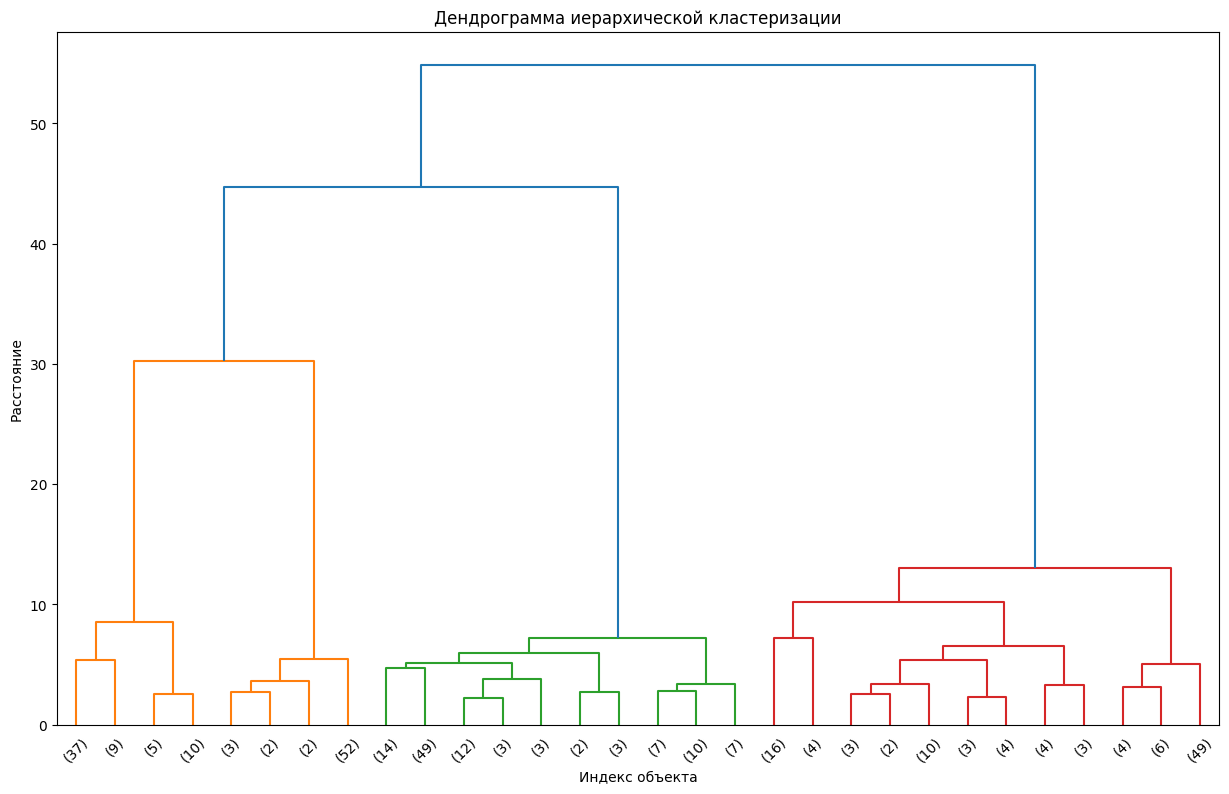

In [41]:
# Выполняем иерархическую кластеризацию с помощью алгоритм минимизации дисперсии Уорда.
linked = linkage(df, method='ward')

# Cтроим дендрограмму
plt.figure(figsize=(15, 9))
dendrogram(linked,
           truncate_mode='lastp', # сжатие в листовые узлы т.к. громозкая дендрограмма
           orientation='top',
           distance_sort='descending') # отображение. первым идёт потом с макс расстоянием между его потомками
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Индекс объекта')
plt.ylabel('Расстояние')
plt.show()

Видим, что выделилось 4 основных класса: Красный, зелёный и два оранжевых класса (не будем объединять в один класс, так как расстояние перед объединением достаточно большое)

In [35]:
K = 4
df['cluster_id']  = fcluster(linked, K, criterion='maxclust')
#смотрим среднее значение признаков для каждого класса для интерпритации кластеров
cluster_analysis = df.groupby('cluster_id').mean().round(2)
cluster_analysis


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
cluster_id,,,,,,,,,,,
1,2.82,2.83,2.77,2.62,2.61,2.58,2.75,2.92,4.95,4.81,4.86
2,4.85,4.80,4.84,4.68,3.04,3.04,3.00,2.99,3.07,3.05,3.05
3,3.00,2.97,2.97,2.92,2.92,2.95,4.92,4.92,3.00,3.00,3.00
4,3.00,3.00,3.00,3.00,4.85,4.85,3.00,2.92,2.75,2.75,2.75


Можем проинтерпритировать результаты класстерного анализа следующим образом:

Кластер 1: леденец как лекарство (преобладание людей, которые используют леденец при боле в горле, насморке или плохом самочувствие)

Кластер 2: леденец для гигиены (освежить дыхание и чувтвовать себя увереннее)

Кластер 3: леденец для стимуляции мозга (улучшить когнетивные способности)

Кластер 4: леденец как сладость (замена сладкого или кондитерских изделий)

Попробуем воспользоваться советом от дендрограмму и разобьём данные на три кластера

In [36]:
K = 3
df['cluster_id']  = fcluster(linked, K, criterion='maxclust')
#смотрим среднее значение признаков для каждого класса для интерпритации кластеров
cluster_analysis = df.groupby('cluster_id').mean().round(2)
cluster_analysis

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
cluster_id,,,,,,,,,,,
1,2.82,2.83,2.77,2.62,2.61,2.58,2.75,2.92,4.95,4.81,4.86
2,4.85,4.80,4.84,4.68,3.04,3.04,3.00,2.99,3.07,3.05,3.05
3,3.00,2.98,2.98,2.96,3.90,3.92,3.94,3.90,2.88,2.88,2.88


Кластеры для замены лекарства и средства гигиены остались, а вот кластеры для умственной стимуляции и замены сладкого слились в один кластер, в котором не выделешь общей тенденции.